## Movie Prediction Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors


# Reading Dataset

In [2]:
movies = pd.read_csv('movies.csv') ## Reading the movies.csv file into a DataFrame called 'movies'


In [3]:
ratings = pd.read_csv('ratings.csv') ## Reading the ratings.csv file into a DataFrame called 'ratings'

In [4]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


In [5]:
ratings

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


## Exploratory Data Analysis (EDA)

In [6]:
movies.head() ## Displaying the first few rows of the 'movies' DataFrame to get an overview of its structure and contents


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
ratings.head() ## Displaying the first few rows of the 'ratings' DataFrame to get an overview of its structure and contents

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [8]:
ratings = ratings.drop('timestamp', axis=1) ## Dropping the 'timestamp' column from the 'ratings' DataFrame as it is not needed for the analysis

In [9]:
ratings.head() ## Displaying the first few rows of the 'ratings' DataFrame to check that the 'timestamp' column has been successfully dropped

,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


In [10]:
movies.shape ### Displaying the shape of the 'movies' DataFrame to see how many rows and columns it contains

(87585, 3)

In [11]:
ratings.shape ### Displaying the shape of the 'ratings' DataFrame to see how many rows and columns it contains

(32000204, 3)

In [12]:
movies.columns ### Displaying the column names of the 'movies' DataFrame to understand its structure

Index(['movieId', 'title', 'genres'], dtype='str')

In [13]:
ratings.columns ### Displaying the column names of the 'ratings' DataFrame to understand its structure

Index(['userId', 'movieId', 'rating'], dtype='str')

In [14]:
movies.info() ### Displaying the summary of the 'movies' DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87585 non-null  int64
 1   title    87585 non-null  str  
 2   genres   87585 non-null  str  
dtypes: int64(1), str(2)
memory usage: 5.2 MB


In [15]:
ratings.info() ### Displaying the summary of the 'ratings' DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 732.4 MB


In [16]:
movies.describe() ### Displaying the statistical summary of the 'movies' DataFrame, including count, mean, standard deviation, min, max, and quartiles for numerical columns

,movieId
count,87585.000000
mean,157651.365519
std,79013.402099
min,1.000000
25%,112657.000000
50%,165741.000000
75%,213203.000000
max,292757.000000


In [17]:
ratings.describe() ### Displaying the statistical summary of the 'ratings' DataFrame, including count, mean, standard deviation, min, max, and quartiles for numerical columns

,userId,movieId,rating
count,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00
std,5.794905e+04,5.095816e+04,1.058986e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,5.005300e+04,1.233000e+03,3.000000e+00
50%,1.002970e+05,3.452000e+03,3.500000e+00
75%,1.504510e+05,4.419900e+04,4.000000e+00
max,2.009480e+05,2.927570e+05,5.000000e+00



## Data Cleaning

In [18]:
movies.isnull().sum() ### Checking for missing values in the 'movies' DataFrame by summing the number of null entries in each column

movieId    0
title      0
genres     0
dtype: int64

In [19]:
ratings.isnull().sum() ### Checking for missing values in the 'ratings' DataFrame by summing the number of null entries in each column

userId     0
movieId    0
rating     0
dtype: int64

In [20]:
movies.duplicated().sum() ### Checking for duplicate rows in the 'movies' DataFrame by summing the number of duplicated entries

np.int64(0)

In [21]:
ratings.duplicated().sum() ### Checking for duplicate rows in the 'ratings' DataFrame by summing the number of duplicated entries

np.int64(0)

In [22]:
movies.nunique() ### Displaying the number of unique values in each column of the 'movies' DataFrame to understand the distribution of data

movieId    87585
title      87382
genres      1798
dtype: int64

In [23]:
ratings.nunique() ### Displaying the number of unique values in each column of the 'ratings' DataFrame to understand the distribution of data

userId     200948
movieId     84432
rating         10
dtype: int64

In [24]:
df = pd.merge(movies, ratings, on='movieId') ### Merging the 'movies' and 'ratings' DataFrames on the 'movieId' column to create a combined DataFrame called 'df'

In [25]:
df.head() ### Displaying the first few rows of the merged DataFrame to check its structure and content

,movieId,title,genres,userId,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,10,2.5
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,3.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.0
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,20,5.0


In [26]:
df.shape ### Displaying the shape of the merged DataFrame to see how many rows and columns it contains


(32000204, 5)

In [27]:
df.info() ### Displaying the summary of the merged DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 5 columns):
 #   Column   Dtype  
---  ------   -----  
 0   movieId  int64  
 1   title    str    
 2   genres   str    
 3   userId   int64  
 4   rating   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.5 GB


In [28]:
df.isnull().sum() ### Checking for missing values in the merged DataFrame by summing the number of null entries in each column

movieId    0
title      0
genres     0
userId     0
rating     0
dtype: int64

In [29]:
rating_count = df.groupby('title')['rating'].count().reset_index(name='rating_count').sort_values('rating_count', ascending=False) ### Grouping the merged DataFrame by 'title' and counting the number of ratings for each movie, then resetting the index and sorting the results in descending order based on the count of ratings

In [30]:
rating_count.head() ### Displaying the first few rows of the 'rating_count' DataFrame to see the movies with the highest number of ratings

,title,rating_count
58799,"Shawshank Redemption, The (1994)",102929
25132,Forrest Gump (1994),100296
53404,Pulp Fiction (1994),98409
42977,"Matrix, The (1999)",93808
59415,"Silence of the Lambs, The (1991)",90330


In [31]:
average_rating = df.groupby('title')['rating'].mean().reset_index(name='average_rating').sort_values('average_rating', ascending=False) ### Grouping the merged DataFrame by 'title' and calculating the average rating for each movie, then resetting the index and sorting the results in descending order based on the average rating

In [32]:
average_rating.head() ### Displaying the first few rows of the 'average_rating' DataFrame to see the movies with the highest average ratings

,title,average_rating
12181,CKY 3 (2001),5.0
30918,Hometown Holiday (2018),5.0
30917,Hometown Hero (2017),5.0
30916,Hometown Christmas (2018),5.0
30905,Homemade Christmas (2020),5.0


In [33]:
movies_stats = pd.merge(
    rating_count,
    average_rating,
    on='title'
)

movies_stats.head()

,title,rating_count,average_rating
0,"Shawshank Redemption, The (1994)",102929,4.404614
1,Forrest Gump (1994),100296,4.052744
2,Pulp Fiction (1994),98409,4.196969
3,"Matrix, The (1999)",93808,4.156437
4,"Silence of the Lambs, The (1991)",90330,4.148367


In [34]:
movies_stats = pd.merge(rating_count, average_rating, on='title') ### Merging the 'rating_count' and 'average_rating' DataFrames on the 'title' column to create a new DataFrame called 'movies_stats' that contains both the count of ratings and the average rating for each movie

In [35]:
movies_stats.head() ### Displaying the first few rows of the 'movies_stats' DataFrame to check its structure and content

,title,rating_count,average_rating
0,"Shawshank Redemption, The (1994)",102929,4.404614
1,Forrest Gump (1994),100296,4.052744
2,Pulp Fiction (1994),98409,4.196969
3,"Matrix, The (1999)",93808,4.156437
4,"Silence of the Lambs, The (1991)",90330,4.148367


In [36]:
movies_stats.sort_values('rating_count', ascending=False).head(10) ### Displaying the top 10 movies with the highest number of ratings by sorting the 'movies_stats' DataFrame in descending order based on the 'rating_count' column and selecting the first 10 rows

,title,rating_count,average_rating
0,"Shawshank Redemption, The (1994)",102929,4.404614
1,Forrest Gump (1994),100296,4.052744
2,Pulp Fiction (1994),98409,4.196969
3,"Matrix, The (1999)",93808,4.156437
4,"Silence of the Lambs, The (1991)",90330,4.148367
5,Star Wars: Episode IV - A New Hope (1977),85010,4.099824
6,Fight Club (1999),77332,4.228780
7,Jurassic Park (1993),75233,3.698623
8,Schindler's List (1993),73849,4.236990
9,"Lord of the Rings: The Fellowship of the Ring,...",73122,4.092134


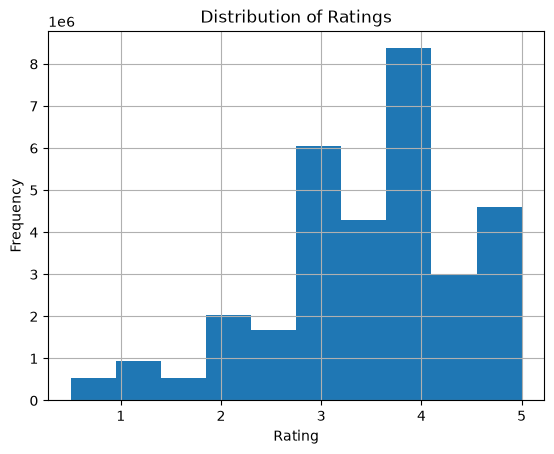

In [37]:
ratings["rating"].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show() ### Creating a histogram to visualize the distribution of ratings in the 'ratings' DataFrame, with 10 bins, and adding titles and labels to the axes

In [38]:
average_rating = df.groupby('title')['rating'].mean().reset_index(name='average_rating')

average_rating['movie_quality'] = average_rating['average_rating'].apply(
    lambda x: 'Good Movie' if x >= 2.5 else 'Bad Movie'
)

average_rating.head()

,title,average_rating,movie_quality
0,(2019),2.657143,Good Movie
1,"""BLOW THE NIGHT!"" Let's Spend the Night Togeth...",2.000000,Bad Movie
2,"""Great Performances"" Cats (1998)",2.917373,Good Movie
3,"""Sr."" (2022)",3.227273,Good Movie
4,#1 Cheerleader Camp (2010),2.000000,Bad Movie


In [39]:
movie_name = "Toy Story (1995)"

average_rating[average_rating['title'] == movie_name][
    ['title', 'average_rating', 'movie_quality']
]


,title,average_rating,movie_quality
77150,Toy Story (1995),3.897438,Good Movie


In [40]:
def recommend_movies(movie_name, n=10):

    if movie_name not in movie_similarity_df.columns:
        return "Movie not found."

    recommendations = (
        movie_similarity_df[movie_name]
        .sort_values(ascending=False)
        .iloc[1:n+1]
        .index
    )

    result = pd.DataFrame({
        'Recommended Movies': recommendations
    })

    result = result.merge(
        average_rating[['title', 'average_rating', 'movie_quality']],
        left_on='Recommended Movies',
        right_on='title',
        how='left'
    )

    return result[['Recommended Movies', 'average_rating', 'movie_quality']]

In [41]:
average_rating.head()

,title,average_rating,movie_quality
0,(2019),2.657143,Good Movie
1,"""BLOW THE NIGHT!"" Let's Spend the Night Togeth...",2.000000,Bad Movie
2,"""Great Performances"" Cats (1998)",2.917373,Good Movie
3,"""Sr."" (2022)",3.227273,Good Movie
4,#1 Cheerleader Camp (2010),2.000000,Bad Movie


In [42]:
print(average_rating.head())

                                               title  average_rating  \
0                                             (2019)        2.657143   
1  "BLOW THE NIGHT!" Let's Spend the Night Togeth...        2.000000   
2                   "Great Performances" Cats (1998)        2.917373   
3                                       "Sr." (2022)        3.227273   
4                         #1 Cheerleader Camp (2010)        2.000000   

  movie_quality  
0    Good Movie  
1     Bad Movie  
2    Good Movie  
3    Good Movie  
4     Bad Movie  


In [43]:
ratings["rating"].value_counts().sort_index() ### Counting the occurrences of each unique rating value in the 'ratings' DataFrame, sorting the results by the rating values, and displaying the counts

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

In [44]:
movies_stats.columns ### Displaying the column names of the 'movies_stats' DataFrame to understand its structure

Index(['title', 'rating_count', 'average_rating'], dtype='str')

In [45]:
df = df.merge(movies_stats, on='title') ### Merging the 'df' DataFrame with the 'movies_stats' DataFrame on the 'title' column to include the rating count and average rating for each movie in the main DataFrame

In [46]:
df.columns ### Displaying the column names of the merged DataFrame to understand its structure after merging with 'movies_stats'

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'rating_count',
       'average_rating'],
      dtype='str')

In [47]:
df.head()

,movieId,title,genres,userId,rating,rating_count,average_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,10,2.5,68997,3.897438
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,3.0,68997,3.897438
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.0,68997,3.897438
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0,68997,3.897438
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,20,5.0,68997,3.897438


In [48]:
movies['genres_list'] = movies['genres'].str.split('|') ### Splitting the 'genres' column in the 'movies' DataFrame into a list of genres for each movie and storing it in a new column called 'genres_list'

In [49]:
movies[['genres', 'genres_list']].head() ### Displaying the first few rows of the 'movies' DataFrame to show both the original 'genres' column and the new 'genres_list' column, allowing for a comparison of the two representations of genres

,genres,genres_list
0,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,Comedy|Romance,"[Comedy, Romance]"
3,Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,Comedy,[Comedy]


In [50]:
movies['genres_list'].dtype ### Checking the data type of the 'genres_list' column in the 'movies' DataFrame to confirm that it is a list

dtype('O')

In [51]:
type(movies['genres_list'].iloc[0]) ### Checking the data type of the first element in the 'genres_list' column to confirm that it is a list

list

In [52]:
movies['genres_list'].apply(len).describe() ### Calculating the length of each list in the 'genres_list' column, applying the 'len' function to each element, and then displaying the statistical summary of these lengths to understand the distribution of the number of genres per movie

count    87585.000000
mean         1.760233
std          0.943453
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: genres_list, dtype: float64

In [53]:
movies['genres'].value_counts().get('(no genres listed)', 0) ### Counting the occurrences of the '(no genres listed)' entry in the 'genres' column of the 'movies' DataFrame to determine how many movies do not have any genres specified

np.int64(7080)

In [54]:
movies_with_genres = movies[movies['genres'] != '(no genres listed)'] ### Creating a new DataFrame called 'movies_with_genres' that contains only the movies that have at least one genre listed by filtering out the rows where the 'genres' column is equal to '(no genres listed)'


In [55]:
df[df['title'].isin(movies[movies['genres']=='(no genres listed)']['title'])]['title'].value_counts().head(10) ### Counting the occurrences of each movie title in the merged DataFrame 'df' that corresponds to movies with '(no genres listed)' in the 'movies' DataFrame, and displaying the top 10 most frequently occurring titles

title
Hereditary (2018)                                          4596
Whiplash (2013)                                            3080
Pirates of the Caribbean: Dead Men Tell No Tales (2017)    3064
Fantastic Beasts and Where to Find Them 2 (2018)           2254
Green Room (2015)                                          2148
Eighth Grade (2018)                                        1614
Paterson                                                   1148
Black Mirror                                               1027
Spectral (2016)                                             658
Pitch Perfect 3 (2017)                                      649
Name: count, dtype: int64

In [56]:
genre_fixes = {
    'Hereditary (2018)': 'Drama|Horror|Mystery',
    'Whiplash (2013)': 'Drama|Music',
    'Pirates of the Caribbean: Dead Men Tell No Tales (2017)': 'Action|Adventure|Fantasy',
    'Green Room (2015)': 'Horror|Thriller',
    'Eighth Grade (2018)': 'Comedy|Drama',
} ### Creating a dictionary called 'genre_fixes' that maps specific movie titles to their corrected genre strings, which will be used to update the 'genres' column in the 'movies' DataFrame for these movies


In [57]:
total_ratings_missing_genre = df[df['genres'] == '(no genres listed)'].shape[0] ### Calculating the total number of ratings in the merged DataFrame 'df' that correspond to movies with '(no genres listed)' in the 'movies' DataFrame by filtering the rows and getting the shape of the resulting DataFrame

In [58]:
movie_stats = df.groupby('title')['rating'].count().reset_index()
movie_stats.rename(columns={'rating':'rating_count'}, inplace=True)

popular_movies = movie_stats[movie_stats['rating_count'] >= 100]

In [59]:
user_stats = df.groupby('userId')['rating'].count().reset_index()
user_stats.rename(columns={'rating': 'rating_count'}, inplace=True)
active_users = user_stats[user_stats['rating_count'] >= 300]

df_filtered = df[
    (df['userId'].isin(active_users['userId'])) &
    (df['title'].isin(popular_movies['title']))
]

In [60]:
print(df_filtered.shape)
print(df_filtered['userId'].nunique())
print(df_filtered['title'].nunique())

(16437089, 7)
26179
12192


In [61]:
user_stats = df.groupby('userId')['rating'].count().reset_index()
user_stats.rename(columns={'rating': 'rating_count'}, inplace=True)

active_users = user_stats[user_stats['rating_count'] >= 300]

df_filtered = df[
    (df['userId'].isin(active_users['userId'])) &
    (df['title'].isin(popular_movies['title']))
]

print(df_filtered.shape)
print(df_filtered['userId'].nunique())
print(df_filtered['title'].nunique())

(16437089, 7)
26179
12192


In [62]:
user_stats = df.groupby('userId')['rating'].count().reset_index()
user_stats.rename(columns={'rating':'rating_count'}, inplace=True)

print(user_stats['rating_count'].describe())

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
Name: rating_count, dtype: float64


In [63]:
print(user_stats[user_stats['rating_count'] >= 500].shape)
print(user_stats[user_stats['rating_count'] >= 1000].shape)
print(user_stats[user_stats['rating_count'] >= 1500].shape)

(12603, 2)
(3621, 2)
(1338, 2)


In [64]:
user_stats = df.groupby('userId')['rating'].count().reset_index()
user_stats.rename(columns={'rating': 'rating_count'}, inplace=True)

active_users = user_stats[user_stats['rating_count'] >= 1000]

In [65]:
df_filtered = df[
    (df['userId'].isin(active_users['userId'])) &
    (df['title'].isin(popular_movies['title']))
]

In [66]:
print(df_filtered.shape)
print(df_filtered['userId'].nunique())
print(df_filtered['title'].nunique())

(5368101, 7)
3621
12192


In [67]:
user_movie_matrix = df_filtered.pivot_table(
    index='userId',
    columns='title',
    values='rating',
    fill_value=0
)

In [68]:
user_movie_matrix.head()

title,"""Great Performances"" Cats (1998)",#Alive (2020),'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,[REC]³ 3 Génesis (2012),eXistenZ (1999),iBoy (2017),loudQUIETloud: A Film About the Pixies (2006),"tick, tick...BOOM! (2021)",xXx (2002),xXx: Return of Xander Cage (2017),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0,...,0.0,4.0,0.0,0.0,4.0,3.0,0.0,0.0,3.0,0.0
188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,0.0,3.5,...,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
265,0.0,3.5,0.0,0.0,0.0,0.0,0.0,3.5,0.0,4.5,...,5.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0
354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
movie_similarity = cosine_similarity(user_movie_matrix.T)

In [70]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

In [71]:
movie_similarity_df.head()

title,"""Great Performances"" Cats (1998)",#Alive (2020),'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,[REC]³ 3 Génesis (2012),eXistenZ (1999),iBoy (2017),loudQUIETloud: A Film About the Pixies (2006),"tick, tick...BOOM! (2021)",xXx (2002),xXx: Return of Xander Cage (2017),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
"""Great Performances"" Cats (1998)",1.000000,0.020091,0.009528,0.000000,0.036024,0.073746,0.000000,0.053012,0.000000,0.080406,...,0.087231,0.078379,0.047078,0.022501,0.089418,0.072549,0.118566,0.071958,0.060156,0.013775
#Alive (2020),0.020091,1.000000,0.073239,0.025773,0.002344,0.032510,0.000000,0.085437,0.000000,0.152831,...,0.163981,0.102868,0.097876,0.000000,0.076956,0.116683,0.070110,0.088401,0.052725,0.025094
'71 (2014),0.009528,0.073239,1.000000,0.005573,0.083175,0.040479,0.001852,0.104285,0.028769,0.230842,...,0.089557,0.163668,0.059931,0.082626,0.094154,0.136556,0.087635,0.084574,0.102010,0.058738
'Hellboy': The Seeds of Creation (2004),0.000000,0.025773,0.005573,1.000000,0.000000,0.058377,0.009573,0.041209,0.000000,0.041434,...,0.038062,0.030215,0.017400,0.071779,0.022574,0.041612,0.049597,0.053421,0.060698,0.000000
'Round Midnight (1986),0.036024,0.002344,0.083175,0.000000,1.000000,0.032996,0.039622,0.076893,0.127300,0.126180,...,0.030779,0.093058,0.017450,0.012253,0.058932,0.065439,0.017685,0.033111,0.099840,0.168880


In [72]:
def recommend_movies(movie_name, n=10):

    if movie_name not in movie_similarity_df.columns:
        return "Movie not found."

    recommendations = (
        movie_similarity_df[movie_name]
        .sort_values(ascending=False)
        .iloc[1:n+1]
        .index
    )

    return pd.DataFrame({
        "Recommended Movies": recommendations
    })

In [73]:
recommend_movies("Toy Story (1995)") ## Calling the 'recommend_movies' function with the movie name "Toy Story (1995)" to get a list of recommended movies based on similarity, and displaying the results

,Recommended Movies
0,Toy Story 2 (1999)
1,Back to the Future (1985)
2,Jurassic Park (1993)
3,Star Wars: Episode IV - A New Hope (1977)
4,Raiders of the Lost Ark (Indiana Jones and the...
5,"Matrix, The (1999)"
6,Shrek (2001)
7,Forrest Gump (1994)
8,Star Wars: Episode V - The Empire Strikes Back...
9,"Silence of the Lambs, The (1991)"


In [74]:
df['movie_status'] = df['rating_count'].apply(
    lambda x: 'Hit' if x >= 100 else 'Flop'
)

In [75]:
df[['title', 'rating_count', 'movie_status']].head()

,title,rating_count,movie_status
0,Toy Story (1995),68997,Hit
1,Toy Story (1995),68997,Hit
2,Toy Story (1995),68997,Hit
3,Toy Story (1995),68997,Hit
4,Toy Story (1995),68997,Hit


In [76]:
df.columns

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'rating_count',
       'average_rating', 'movie_status'],
      dtype='str')

In [77]:
y = df['movie_status']

In [78]:
df['movie_status'].value_counts()

movie_status
Hit     31230037
Flop      770167
Name: count, dtype: int64

In [79]:
movie_df = df[['movieId', 'title', 'genres', 'average_rating', 'rating_count', 'movie_status']].drop_duplicates()

movie_df.head()

,movieId,title,genres,average_rating,rating_count,movie_status
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997,Hit
68997,2,Jumanji (1995),Adventure|Children|Fantasy,3.275758,28904,Hit
97901,3,Grumpier Old Men (1995),Comedy|Romance,3.139447,13134,Hit
111035,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.845331,2806,Hit
113841,5,Father of the Bride Part II (1995),Comedy,3.059602,13154,Hit


In [80]:
movie_df['movie_status'].value_counts()

movie_status
Flop    72192
Hit     12240
Name: count, dtype: int64

In [81]:
movie_df['genres'].head()

0         Adventure|Animation|Children|Comedy|Fantasy
68997                      Adventure|Children|Fantasy
97901                                  Comedy|Romance
111035                           Comedy|Drama|Romance
113841                                         Comedy
Name: genres, dtype: str

In [82]:
from sklearn.preprocessing import MultiLabelBinarizer

movie_df['genres_list'] = movie_df['genres'].str.split('|')

In [83]:
mlb = MultiLabelBinarizer()

genre_matrix = mlb.fit_transform(movie_df['genres_list'])

genre_df = pd.DataFrame(
    genre_matrix,
    columns=mlb.classes_,
    index=movie_df.index
)

In [84]:
genre_df.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
68997,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
97901,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
111035,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
113841,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [85]:
X = pd.concat([genre_df, movie_df[['average_rating']]], axis=1)

y = movie_df['movie_status']

In [86]:
print(X.shape)
print(y.shape)


(84432, 21)
(84432,)


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [88]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [89]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,   # Try 500 or even 1000
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [90]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

In [91]:
class_weight="balanced"

In [92]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [93]:
y_pred = model.predict(X_test)

In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Flop       0.96      0.71      0.82     14439
         Hit       0.33      0.83      0.47      2448

    accuracy                           0.73     16887
   macro avg       0.64      0.77      0.64     16887
weighted avg       0.87      0.73      0.77     16887



In [95]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [96]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

        Flop       0.93      0.63      0.75     14439
         Hit       0.25      0.72      0.37      2448

    accuracy                           0.65     16887
   macro avg       0.59      0.68      0.56     16887
weighted avg       0.83      0.65      0.70     16887



In [97]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [98]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [99]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train_enc)

y_pred_xgb = xgb.predict(X_test)

In [100]:
y_pred_xgb = le.inverse_transform(y_pred_xgb)

In [101]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

        Flop       0.90      0.97      0.93     14439
         Hit       0.64      0.33      0.44      2448

    accuracy                           0.88     16887
   macro avg       0.77      0.65      0.68     16887
weighted avg       0.86      0.88      0.86     16887



In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Encode target for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

# Train and evaluate sklearn models
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="Hit"),
        "Recall": recall_score(y_test, y_pred, pos_label="Hit"),
        "F1 Score": f1_score(y_test, y_pred, pos_label="Hit")
    })

# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train_enc)

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb)

results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, pos_label="Hit"),
    "Recall": recall_score(y_test, y_pred_xgb, pos_label="Hit"),
    "F1 Score": f1_score(y_test, y_pred_xgb, pos_label="Hit")
})

comparison = pd.DataFrame(results).sort_values(
    by="F1 Score",
    ascending=False
)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  0.778291   0.382990  0.866422  0.531180
2        Random Forest  0.839225   0.457659  0.589461  0.515265
4              XGBoost  0.875703   0.635798  0.333742  0.437718
0  Logistic Regression  0.646770   0.249822  0.717320  0.370581
3    Gradient Boosting  0.868952   0.765237  0.138480  0.234521


In [103]:
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [104]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
comparison.style\
    .hide(axis="index")\
    .background_gradient(subset=["F1 Score"], cmap="Greens")\
    .background_gradient(subset=["Accuracy"], cmap="Blues")\
    .format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1 Score": "{:.2f}%"
    })

Model,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.78%,0.38%,0.87%,0.53%
Random Forest,0.84%,0.46%,0.59%,0.52%
XGBoost,0.88%,0.64%,0.33%,0.44%
Logistic Regression,0.65%,0.25%,0.72%,0.37%
Gradient Boosting,0.87%,0.77%,0.14%,0.23%


In [106]:
movie_df["year"] = movie_df["title"].str.extract(r"\((\d{4})\)")
movie_df["year"] = pd.to_numeric(movie_df["year"], errors="coerce")

In [107]:
movie_df[["title","year"]].head()

,title,year
0,Toy Story (1995),1995.0
68997,Jumanji (1995),1995.0
97901,Grumpier Old Men (1995),1995.0
111035,Waiting to Exhale (1995),1995.0
113841,Father of the Bride Part II (1995),1995.0


In [108]:
# Create number of genres
movie_df["num_genres"] = movie_df["genres_list"].apply(len)

# Create movie age
current_year = 2026
movie_df["movie_age"] = current_year - movie_df["year"]

# Verify
print(movie_df[["year", "movie_age", "num_genres"]].head())

          year  movie_age  num_genres
0       1995.0       31.0           5
68997   1995.0       31.0           3
97901   1995.0       31.0           2
111035  1995.0       31.0           3
113841  1995.0       31.0           1


In [109]:
print(movie_df.columns.tolist())

['movieId', 'title', 'genres', 'average_rating', 'rating_count', 'movie_status', 'genres_list', 'year', 'num_genres', 'movie_age']


In [110]:
X = pd.concat(
    [
        genre_df,
        movie_df[
            [
                "average_rating",
                "year",
                "movie_age",
                "num_genres"
            ]
        ]
    ],
    axis=1
)

y = movie_df["movie_status"]

print(X.head())
print(X.shape)

        (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                        0       0          1          1         1       1   
68997                    0       0          1          0         1       0   
97901                    0       0          0          0         0       1   
111035                   0       0          0          0         0       1   
113841                   0       0          0          0         0       1   

        Crime  Documentary  Drama  Fantasy  ...  Mystery  Romance  Sci-Fi  \
0           0            0      0        1  ...        0        0       0   
68997       0            0      0        1  ...        0        0       0   
97901       0            0      0        0  ...        0        1       0   
111035      0            0      1        0  ...        0        1       0   
113841      0            0      0        0  ...        0        0       0   

        Thriller  War  Western  average_rating    year  movie_age  n

In [111]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "class_weight":["balanced"]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

best_rf = search.best_estimator_

print(search.best_params_)

c:\Users\haan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}


In [112]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [113]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [114]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train_enc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [115]:
best_xgb = xgb_search.best_estimator_

print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [116]:
y_pred_xgb = best_xgb.predict(X_test)

# Convert numeric predictions back to Hit/Flop
y_pred_xgb = le.inverse_transform(y_pred_xgb)

In [117]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("TUNED XGBOOST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}\n")

print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

TUNED XGBOOST RESULTS
Accuracy : 0.8758

              precision    recall  f1-score   support

        Flop       0.90      0.96      0.93     14439
         Hit       0.62      0.36      0.46      2448

    accuracy                           0.88     16887
   macro avg       0.76      0.66      0.69     16887
weighted avg       0.86      0.88      0.86     16887

Confusion Matrix
[[13904   535]
 [ 1562   886]]


In [118]:
ratio = (y_train == "Flop").sum() / (y_train == "Hit").sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)

In [119]:
import joblib

joblib.dump(best_xgb, "movie_hit_flop_model.pkl")
joblib.dump(mlb, "genre_encoder.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [120]:
print(model.feature_names_in_)

['(no genres listed)' 'Action' 'Adventure' 'Animation' 'Children' 'Comedy'
 'Crime' 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'IMAX'
 'Musical' 'Mystery' 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western'
 'average_rating']


In [121]:
print(genre_df.columns.tolist())

['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [122]:
print(genre_df.columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='str')


In [123]:
# ==========================================
# SAVE DATA FOR STREAMLIT RECOMMENDATION APP
# ==========================================

import joblib

# Keep the movie information needed by the app
movie_data = movie_df[
    [
        "movieId",
        "title",
        "genres",
        "average_rating",
        "rating_count",
        "year",
        "movie_age",
        "num_genres"
    ]
].copy()

# Save movie information
joblib.dump(movie_data, "movie_data.pkl")

# Save genre features
joblib.dump(genre_df, "genre_features.pkl")

print("Files saved successfully!")

Files saved successfully!


In [124]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_movies(movie_title, n=10):

    # Find movie
    matches = movie_data[
        movie_data["title"].str.lower() == movie_title.lower()
    ]

    if matches.empty:
        return pd.DataFrame()

    movie_index = matches.index[0]

    # Get genre vector for selected movie
    selected_genres = genre_df.loc[[movie_index]]

    # Calculate similarity against all movies
    similarities = cosine_similarity(
        selected_genres,
        genre_df
    )[0]

    # Get top similar movies
    similar_indices = similarities.argsort()[::-1]

    # Remove selected movie
    similar_indices = [
        i for i in similar_indices
        if genre_df.index[i] != movie_index
    ]

    top_indices = similar_indices[:n]

    recommendations = movie_data[
        movie_data.index.isin(
            genre_df.index[top_indices]
        )
    ].copy()

    # Preserve similarity order
    similarity_map = {
        genre_df.index[i]: similarities[i]
        for i in top_indices
    }

    recommendations["similarity"] = recommendations.index.map(
        similarity_map
    )

    recommendations = recommendations.sort_values(
        "similarity",
        ascending=False
    )

    return recommendations[
        [
            "title",
            "genres",
            "average_rating",
            "year",
            "similarity"
        ]
    ]

In [125]:
recommend_movies("Toy Story (1995)")

,title,genres,average_rating,year,similarity
23341389,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy,3.274590,1990.0,1.0
31245724,Tangled: Before Ever After (2017),Adventure|Animation|Children|Comedy|Fantasy,2.867647,2017.0,1.0
31245808,Trolls Holiday (2017),Adventure|Animation|Children|Comedy|Fantasy,2.772727,2017.0,1.0
31490317,Wonder Park (2019),Adventure|Animation|Children|Comedy|Fantasy,2.618644,2019.0,1.0
31572205,UglyDolls (2019),Adventure|Animation|Children|Comedy|Fantasy,2.194444,2019.0,1.0
31775592,Soul (2020),Adventure|Animation|Children|Comedy|Fantasy,3.911948,2020.0,1.0
31794385,The SpongeBob Movie: Sponge on the Run (2020),Adventure|Animation|Children|Comedy|Fantasy,2.706897,2020.0,1.0
31808299,Legends of Valhalla: Thor (2011),Adventure|Animation|Children|Comedy|Fantasy,4.500000,2011.0,1.0
31970210,My Father's Dragon (2022),Adventure|Animation|Children|Comedy|Fantasy,3.272727,2022.0,1.0
31972414,Puss in Boots: The Last Wish (2022),Adventure|Animation|Children|Comedy|Fantasy,3.921983,2022.0,1.0


In [126]:
print(model.classes_)

['Flop' 'Hit']


In [127]:
print(model.feature_names_in_)

['(no genres listed)' 'Action' 'Adventure' 'Animation' 'Children' 'Comedy'
 'Crime' 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'IMAX'
 'Musical' 'Mystery' 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western'
 'average_rating']


In [128]:
test = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)

test["Animation"] = 1
test["average_rating"] = 5.0
test["year"] = 2026
test["movie_age"] = 0
test["num_genres"] = 1

print(test)
print("Prediction:", model.predict(test))
print("Probability:", model.predict_proba(test))

   (no genres listed)  Action  Adventure  Animation  Children  Comedy  Crime  \
0                   0       0          0          1         0       0      0   

   Documentary  Drama  Fantasy  ...  Mystery  Romance  Sci-Fi  Thriller  War  \
0            0      0        0  ...        0        0       0         0    0   

   Western  average_rating  year  movie_age  num_genres  
0        0             5.0  2026          0           1  

[1 rows x 24 columns]


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- movie_age
- num_genres
- year


In [129]:
print("MODEL CLASSES:")
print(model.classes_)

MODEL CLASSES:
['Flop' 'Hit']


In [130]:
print("TARGET COUNTS:")
print(y.value_counts())

TARGET COUNTS:
movie_status
Flop    72192
Hit     12240
Name: count, dtype: int64


In [131]:
print("TARGET VALUES:")
print(y.unique())

TARGET VALUES:
<ArrowStringArray>
['Hit', 'Flop']
Length: 2, dtype: str


In [133]:
print(model.feature_names_in_)

['(no genres listed)' 'Action' 'Adventure' 'Animation' 'Children' 'Comedy'
 'Crime' 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'IMAX'
 'Musical' 'Mystery' 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western'
 'average_rating']


In [134]:
test = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)

test["Animation"] = 1
test["average_rating"] = 5.0

print("Prediction:")
print(model.predict(test))

print("Probability:")
print(model.predict_proba(test))

Prediction:
['Flop']
Probability:
[[0.97877471 0.02122529]]


In [135]:
test2 = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)

test2["Horror"] = 1
test2["average_rating"] = 1.0

print("Prediction:")
print(model.predict(test2))

print("Probability:")
print(model.predict_proba(test2))

Prediction:
['Flop']
Probability:
[[0.98154064 0.01845936]]


In [136]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(67545, 21)
(16887, 21)
movie_status
Flop    57753
Hit      9792
Name: count, dtype: int64
movie_status
Flop    14439
Hit      2448
Name: count, dtype: int64


In [137]:
print(X_train.columns.tolist())

['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'average_rating']


In [139]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print(target_encoder.classes_)

['Flop' 'Hit']


In [140]:
from xgboost import XGBClassifier

flop_count = (y_train == "Flop").sum()
hit_count = (y_train == "Hit").sum()

scale_pos_weight = flop_count / hit_count

print("Scale Pos Weight:", scale_pos_weight)

balanced_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

balanced_xgb.fit(
    X_train,
    y_train_encoded
)

Scale Pos Weight: 5.897977941176471


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [141]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = balanced_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.766329128915734

Classification Report:
              precision    recall  f1-score   support

        Flop       0.98      0.74      0.84     14439
         Hit       0.37      0.90      0.53      2448

    accuracy                           0.77     16887
   macro avg       0.68      0.82      0.69     16887
weighted avg       0.89      0.77      0.80     16887


Confusion Matrix:
[[10737  3702]
 [  244  2204]]


In [142]:
test = pd.DataFrame(
    0,
    index=[0],
    columns=X_train.columns
)

test["Animation"] = 1
test["average_rating"] = 5.0

prediction = balanced_xgb.predict(test)[0]
probability = balanced_xgb.predict_proba(test)[0]

print("Prediction:", target_encoder.inverse_transform([prediction])[0])
print("Flop Probability:", probability[0])
print("Hit Probability:", probability[1])

Prediction: Flop
Flop Probability: 0.99868554
Hit Probability: 0.0013144616


In [143]:
test2 = pd.DataFrame(
    0,
    index=[0],
    columns=X_train.columns
)

test2["Horror"] = 1
test2["average_rating"] = 1.0

prediction2 = balanced_xgb.predict(test2)[0]
probability2 = balanced_xgb.predict_proba(test2)[0]

print("Prediction:", target_encoder.inverse_transform([prediction2])[0])
print("Flop Probability:", probability2[0])
print("Hit Probability:", probability2[1])

Prediction: Flop
Flop Probability: 0.99397326
Hit Probability: 0.006026774


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# --- Test-set classification report ---
y_pred_balanced = balanced_xgb.predict(X_test)

print("CLASSIFICATION REPORT (balanced_xgb on test set)")
print(classification_report(
    y_test_encoded,
    y_pred_balanced,
    target_names=target_encoder.classes_
))
print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test_encoded, y_pred_balanced))

# --- Custom test cases ---
for label, sample in [("test", test), ("test2", test2)]:
    pred_idx = balanced_xgb.predict(sample)[0]
    proba = balanced_xgb.predict_proba(sample)[0]
    pred_label = target_encoder.inverse_transform([pred_idx])[0]

    print(f"\n=== {label.upper()} RESULT ===")
    print(sample)
    print("Prediction:", pred_label)
    print("Probabilities:", dict(zip(target_encoder.classes_, proba)))